## Run inference
### Using TorchIO to replace the standard pytorch dataloader and the custom patch-processor. 

In [1]:
import torch
import torchio as tio
import os
import numpy as np
from skimage import io
import sys 
import yaml
module_path = os.path.abspath(os.path.join('..'))
if module_path not in sys.path:
    sys.path.append(module_path)

from models import networks
from models import create_model
from data import base_dataset



### Set the parameters for the inference 

In [2]:
yaml_file = '../configs/kaarjel-inference-config-20250317-2.yaml'
with open(yaml_file, "r") as f:
    yaml_config = yaml.safe_load(f)

In [3]:
class DummpyOptions():
    def __init__(self):

        self.initialized = False
    
    def gather_options(self, yaml_config):
        
        recursive_attr(self, yaml_config)
        return self
    
@staticmethod
def recursive_attr(class_instance, dict_):
    '''
    If YAML file contains a nested dictionary, this function will iterate to the deepest depth to parse all configs
    '''
    for k, v in dict_.items():
        if isinstance(v, dict):
            new_dict =  dict(zip(v.keys(), v.values()))
            recursive_attr(class_instance, new_dict)
        else:
            setattr(class_instance, k, v)


In [4]:
opt = DummpyOptions()
opt.gather_options(yaml_config)

model = create_model(opt)  # create a model given opt.model and other options
model.setup(opt) 

initialize network with kaiming
model [TestModel] was created
loading the model from /scratch/park/checkpoints/models/DeepClarity/kaarjel-1st-Surt-randomized-projection-depth_exp_250317-171028/iter_117500_net_G_A.pth
---------- Networks initialized -------------
[Network G_A] Total number of parameters : 7.077 M
-----------------------------------------------


/g/kreshuk/park/code/neuroclear/models/base_model.py:199: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = torch.load(load_path, map_location=str(self.device))


## Save Directory

In [5]:
print (opt.__dict__)

{'initialized': False, 'device': 'cuda', 'name': 'kaarjel-1st-Surt-randomized-projection-depth_exp_250317-171028', 'load_iter': 117500, 'phase': 'test', 'checkpoints_dir': '/scratch/park/checkpoints/models/DeepClarity', 'results_dir': '/scratch/park/results/DeepClarity', 'skip_real': True, 'verbose': False, 'save_volume': True, 'eval': True, 'batch_size': 1, 'gpu_ids': [0], 'preprocess': 'addColorChannel', 'border_cut': 20, 'dice_size': 140, 'overlap': 15, 'data_type': 'uint16', 'data_source': '/scratch/park/data/Koehler/Oane', 'image_dimension': 3, 'direction': 'AtoB', 'serial_batches': False, 'model': 'test', 'model_suffix': '_A', 'input_nc': 1, 'output_nc': 1, 'ngf': 64, 'netG': 'unet_deconv', 'norm': 'instance_with_trackstats', 'init_type': 'kaiming', 'init_gain': 0.02, 'no_dropout': False, 'isTrain': False, 'lr': 0.0001, 'beta1': 0.1, 'momentum': 0.9, 'lr_policy': 'constant', 'save_epoch_freq': 1, 'display_freq': 1000, 'visual_projection_depth': 20}


In [6]:
data_source_folder = '/scratch/park/data/Kaarjel/1st_training/confocal'
data_target_folder = '/scratch/park/data/Kaarjel/1st_training/STED'

In [7]:
import os

# Fetch all 'tif' images in the data_source_folder
tif_images_source = [os.path.join(data_source_folder, f) for f in os.listdir(data_source_folder) if f.endswith('.tif')]
print(tif_images_source)
print(f"image # from source: {len(tif_images_source)}")

tif_images_target = [os.path.join(data_target_folder, f) for f in os.listdir(data_target_folder) if f.endswith('.tif')]
print(tif_images_target)
print(f"image # from target: {len(tif_images_target)}")

['/scratch/park/data/Kaarjel/1st_training/confocal/241206_cryoNUP_SD-C_7E-01-Airyscan Processing-03.czi - 241206_cryoNUP_SD-C_7E-01-Airyscan Processing-03.czi #3 - C=0-1_voxel0pt1_crop-1.tif', '/scratch/park/data/Kaarjel/1st_training/confocal/241206_cryoNUP_SD-C_3E-01-Airyscan Processing-10.czi - C=0_voxel0pt1-normd.tif', '/scratch/park/data/Kaarjel/1st_training/confocal/241206_cryoNUP_SD-C_7D-01-Airyscan Processing-07.czi - C=0_voxel0pt1_crop-1.tif', '/scratch/park/data/Kaarjel/1st_training/confocal/241206_cryoNUP_SD-C_4F-01-Airyscan Processing-01.czi - 241206_cryoNUP_SD-C_4F-01-Airyscan Processing-01.czi #2 - C=0_voxel0pt1_crop-1.tif', '/scratch/park/data/Kaarjel/1st_training/confocal/241206_cryoNUP_SD-C_4F-02-Airyscan Processing-02.czi - C=0_voxel0pt1_crop-1.tif', '/scratch/park/data/Kaarjel/1st_training/confocal/241206_cryoNUP_SD-C_7E-01-Airyscan Processing-03.czi - 241206_cryoNUP_SD-C_7E-01-Airyscan Processing-03.czi #2 - C=0-1_voxel0pt1_crop-1.tif', '/scratch/park/data/Kaarjel/1s

In [8]:
index = 1

In [9]:
os.path.basename(tif_images_target[index])[:-4]

'241129_SD-C_TauSTED_NUP96_241129_SD-C_Tau_3E_z0_ch00_voxel0pt1_crop'

In [10]:
import tifffile as tiff

save_dir = '/scratch/park/results/DeepClarity/20250318/' + opt.name 
if not os.path.exists(save_dir):
    os.makedirs(save_dir)

save_output_file = os.path.join(save_dir, opt.name + f'{os.path.basename(tif_images_target[index])[:-4]}_output.tif')
save_input_file = os.path.join(save_dir, f'{os.path.basename(tif_images_target[index])[:-4]}_input.tif')

In [11]:
test_source_img_raw = io.imread(tif_images_source[index])
test_target_img_raw= io.imread(tif_images_target[index])

test_source_img = np.transpose(test_source_img_raw, axes=(2, 1, 0))
test_target_img = np.transpose(test_target_img_raw, axes=(2, 1, 0))

# Add an extra dimension to the tensors
test_source_img = torch.unsqueeze(torch.tensor(test_source_img), 0)
test_target_img = torch.unsqueeze(torch.tensor(test_target_img), 0)
print(test_source_img.shape)

torch.Size([1, 257, 466, 62])


### Note: TorchIO handles the dimension as in reverse: (C, W, H, D) or (C, X, Y, Z). 

In [12]:
subject_source = tio.Subject(
    image=tio.ScalarImage(tensor=test_source_img),
)
patch_size = 128, 128, 48 # x, y, z 
patch_overlap = 20

# patch_size = 256, 256, 24 # x, y, z 
# patch_overlap = 10

In [13]:
grid_sampler = tio.inference.GridSampler(subject_source, patch_size, patch_overlap)
patch_loader = tio.SubjectsLoader(grid_sampler, batch_size=1)
aggregator_output = tio.inference.GridAggregator(grid_sampler, overlap_mode = 'hann')
aggregator_input = tio.inference.GridAggregator(grid_sampler, overlap_mode = 'hann')

In [14]:
len(patch_loader)

30

In [15]:
grid_sampler[0].image['data'].shape

torch.Size([1, 128, 128, 48])

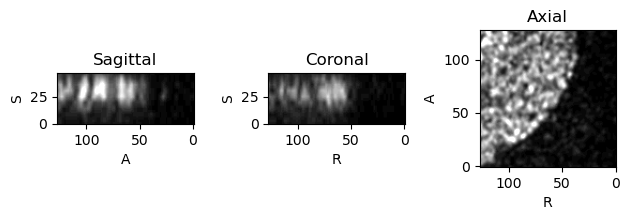

In [16]:
grid_sampler[0].image.plot()

In [17]:
from tqdm.notebook import tqdm

# Iterate over the patches and place them back into the reconstructed volume
with torch.no_grad():
    for patch in tqdm(patch_loader, desc="Processing patches"):
        patch_data = patch['image'][tio.DATA] # (B, C, H, W, D)
        patch_data = patch_data.permute(0, 1, 4, 2, 3) # (B, C, D, H, W)
        patch_data = (patch_data / (2**16*1.0 - 1))
        patch_data_dict = {'src': patch_data, 'src_paths': 'dummy'}
        
        model.set_input(patch_data_dict)
        model.test()
        output = model.get_current_visuals()['fake']
        input_ = model.get_current_visuals()['real']

        # output = (output - output.min()) / (output.max() - output.min())
        # print (patch_data.shape)
        # output = netG(patch_data)
        output = output.permute(0, 1, 3, 4, 2) # (B, C, H, W, D)
        input_ = input_.permute(0, 1, 3, 4, 2)
        aggregator_output.add_batch(output, patch[tio.LOCATION])
        aggregator_input.add_batch(input_, patch[tio.LOCATION])

        # print(patch_data.shape)

Processing patches:   0%|          | 0/30 [00:00<?, ?it/s]

## Visualize one block 

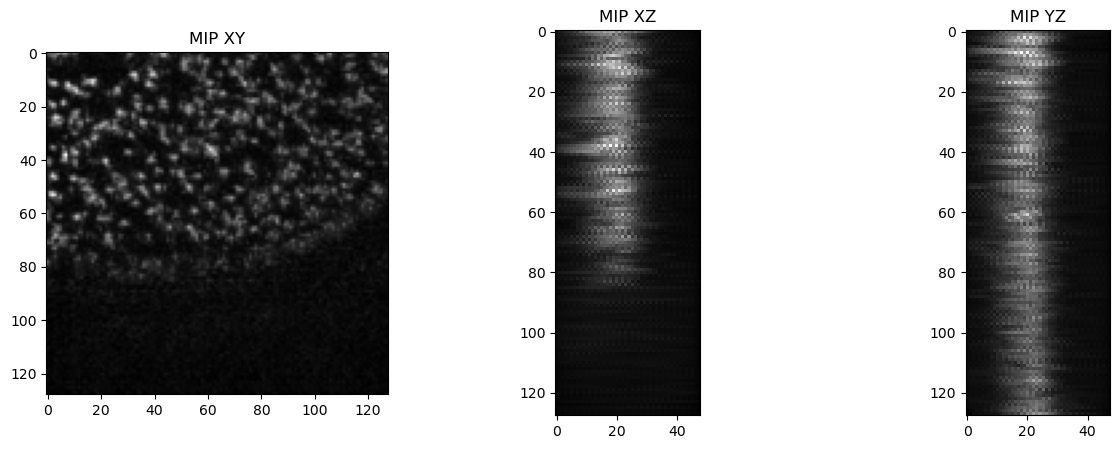

In [18]:
import matplotlib.pyplot as plt

# Convert the tensor to numpy array for visualization
output_np = output.cpu().numpy().squeeze()


# Compute the maximum intensity projection along each axis
mip_xy = np.max(output_np, axis=2)
mip_xz = np.max(output_np, axis=1)
mip_yz = np.max(output_np, axis=0)

# Plot the maximum intensity projections
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(mip_xy, cmap='gray')
axes[0].set_title('MIP XY')

axes[1].imshow(mip_xz, cmap='gray')
axes[1].set_title('MIP XZ')

axes[2].imshow(mip_yz, cmap='gray')
axes[2].set_title('MIP YZ')

plt.show()

In [19]:
output_tensor = aggregator_output.get_output_tensor().squeeze()
output_tensor = output_tensor.permute(2, 0, 1) # (B, C, D, H, W)

input_tensor = aggregator_input.get_output_tensor().squeeze()
input_tensor = input_tensor.permute(2, 0, 1)

In [20]:
output_tensor.shape

torch.Size([62, 257, 466])

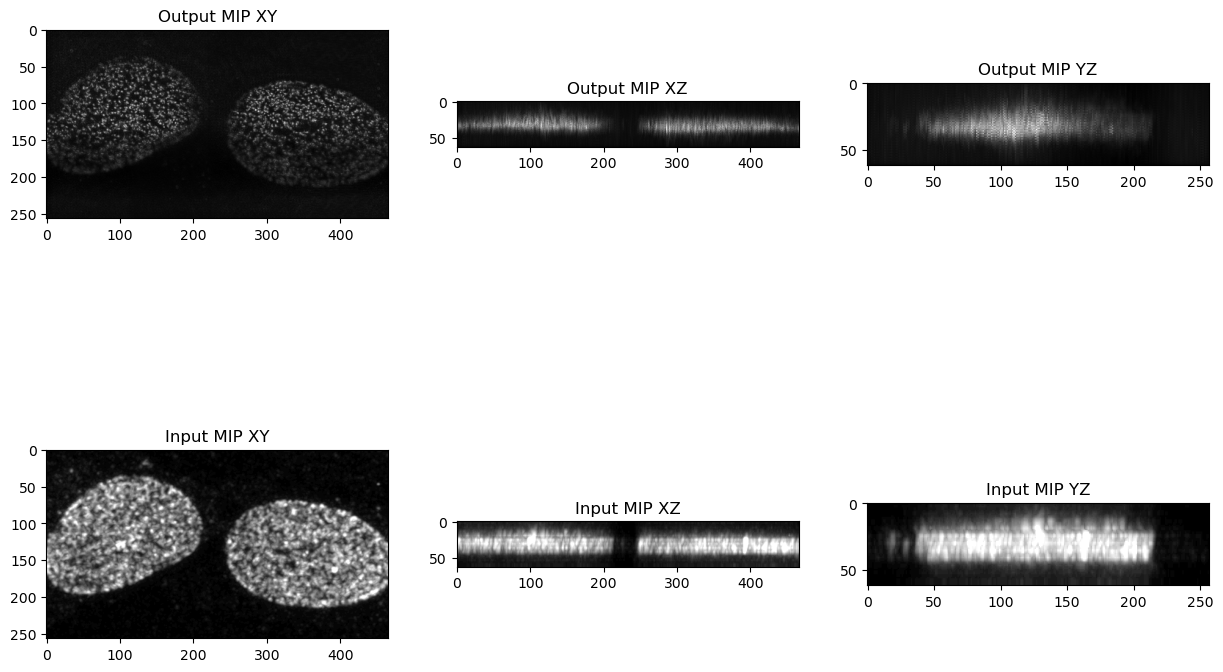

In [21]:
# Convert the input tensor to numpy array for visualization
input_np = input_tensor.cpu().numpy().squeeze()
output_np = output_tensor.cpu().numpy().squeeze()

mip_xy_output = np.max(output_np, axis=0)
mip_xz_output = np.max(output_np, axis=1)
mip_yz_output = np.max(output_np, axis=2)

# Compute the maximum intensity projection along each axis
mip_xy_input = np.max(input_np, axis=0)
mip_xz_input = np.max(input_np, axis=1)
mip_yz_input = np.max(input_np, axis=2)

# Plot the maximum intensity projections
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

axes[0, 0].imshow(mip_xy_output, cmap='gray')
axes[0, 0].set_title('Output MIP XY')

axes[0, 1].imshow(mip_xz_output, cmap='gray')
axes[0, 1].set_title('Output MIP XZ')

axes[0, 2].imshow(mip_yz_output, cmap='gray')
axes[0, 2].set_title('Output MIP YZ')

axes[1, 0].imshow(mip_xy_input, cmap='gray')
axes[1, 0].set_title('Input MIP XY')

axes[1, 1].imshow(mip_xz_input, cmap='gray')
axes[1, 1].set_title('Input MIP XZ')

axes[1, 2].imshow(mip_yz_input, cmap='gray')
axes[1, 2].set_title('Input MIP YZ')

plt.show()

In [22]:
# Normalize the output_np array to the range [0, 65535] for 16-bit
# output_np = np.clip(output_np, 0, 1)
output_np = (output_np - output_np.min()) / (output_np.max() - output_np.min())
output_np = (output_np * 65535).astype(np.uint16)

input_np = (input_np - input_np.min()) / (input_np.max() - input_np.min())
input_np = (input_np * 65535).astype(np.uint16)
# Save the numpy array as a TIFF file
tiff.imwrite(save_output_file, output_np)
tiff.imwrite(save_input_file, input_np)


In [23]:
output_np.shape

(62, 257, 466)

In [24]:
output_np.shape

(62, 257, 466)

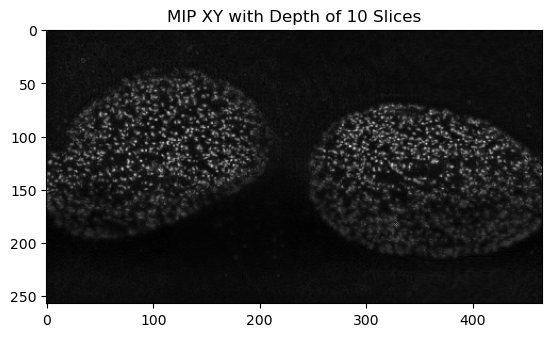

In [25]:
depth = 10
mip_xy_depth = np.max(output_np[30:40,:,:], axis=0)
mip_xy_depth_tensor = torch.unsqueeze(torch.tensor(mip_xy_depth, dtype=torch.float32), dim=0)
plt.imshow(mip_xy_depth, cmap='gray')
plt.title('MIP XY with Depth of 10 Slices')
plt.show()

In [26]:
from pytorch_grad_cam import GradCAM, HiResCAM, ScoreCAM, GradCAMPlusPlus, AblationCAM, XGradCAM, EigenCAM, FullGrad
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from pytorch_grad_cam.utils.image import show_cam_on_image
from torchvision.models import resnet50



model = networks.define_D(1, 64, 'basic',
                                        3, 'instance_with_trackstats','kaiming', 0.02, False,
                                        [0], dimension=2)

model_path = '/scratch/park/checkpoints/models/DeepClarity/kaarjel-1st-Surt-randomized-projection-depth_exp_250317-171028/iter_17500_net_D_A_lateral.pth'
model.load_state_dict(torch.load(model_path, map_location=torch.device('cpu')))
model.eval()

initialize network with kaiming


/tmp/ipykernel_3415250/4203867592.py:13: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(model_path, map_location=torch.device('cpu')))


NLayerDiscriminator(
  (model): Sequential(
    (0): Conv2d(1, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (1): LeakyReLU(negative_slope=0.2, inplace=True)
    (2): Conv2d(64, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (3): InstanceNorm2d(128, eps=1e-05, momentum=0.1, affine=False, track_running_stats=True)
    (4): LeakyReLU(negative_slope=0.2, inplace=True)
    (5): Conv2d(128, 256, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (6): InstanceNorm2d(256, eps=1e-05, momentum=0.1, affine=False, track_running_stats=True)
    (7): LeakyReLU(negative_slope=0.2, inplace=True)
    (8): Conv2d(256, 512, kernel_size=(4, 4), stride=(1, 1), padding=(1, 1))
    (9): InstanceNorm2d(512, eps=1e-05, momentum=0.1, affine=False, track_running_stats=True)
    (10): LeakyReLU(negative_slope=0.2, inplace=True)
    (11): Conv2d(512, 1, kernel_size=(4, 4), stride=(1, 1), padding=(1, 1))
  )
)

In [27]:
last_layer = model.model[-1]
print(last_layer)

Conv2d(512, 1, kernel_size=(4, 4), stride=(1, 1), padding=(1, 1))


In [28]:
# Perform a forward pass
input_tensor = torch.unsqueeze(mip_xy_depth_tensor.cuda(), dim=0)
print (input_tensor.shape)

torch.Size([1, 1, 257, 466])


In [29]:
from torchcam.methods import GradCAM
from torchcam.utils import overlay_mask
import numpy as np
import matplotlib.pyplot as plt

# Identify the second last convolutional layer
target_layer = model.model[-1]  # Change this if using a different architecture

# Initialize Grad-CAM
cam_extractor = GradCAM(model, target_layer=target_layer)


output = model(input_tensor)
predicted_class = 0  # Set to 0 since the model's output has only one class

# Compute Grad-CAM heatmap
activation_map = cam_extractor(predicted_class, output)

# Normalize the heatmap
activation_map = activation_map[0].cpu().detach().numpy()
activation_map = (activation_map - activation_map.min()) / (activation_map.max() - activation_map.min())

In [30]:
activation_map.shape

(1, 30, 56)

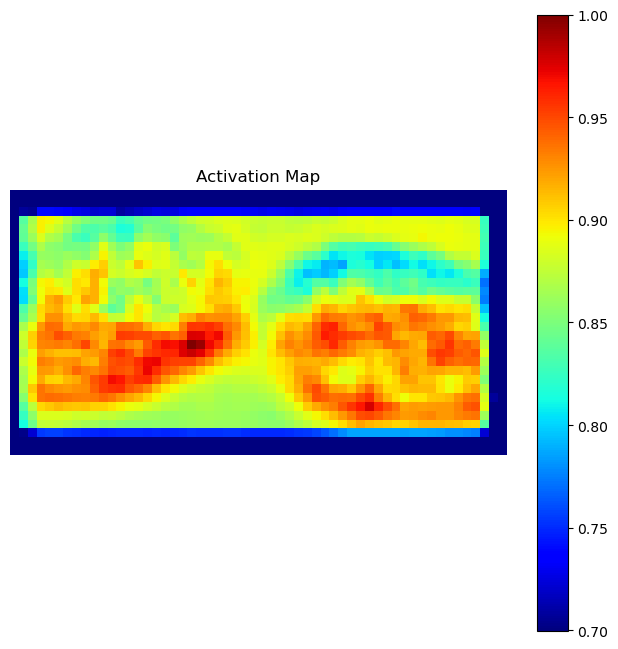

In [31]:
plt.figure(figsize=(8, 8))
plt.imshow(activation_map.squeeze(), cmap='jet', vmin=0.7, vmax=1.0)
plt.colorbar()
plt.title('Activation Map')
plt.axis('off')
plt.show()

(257, 466)


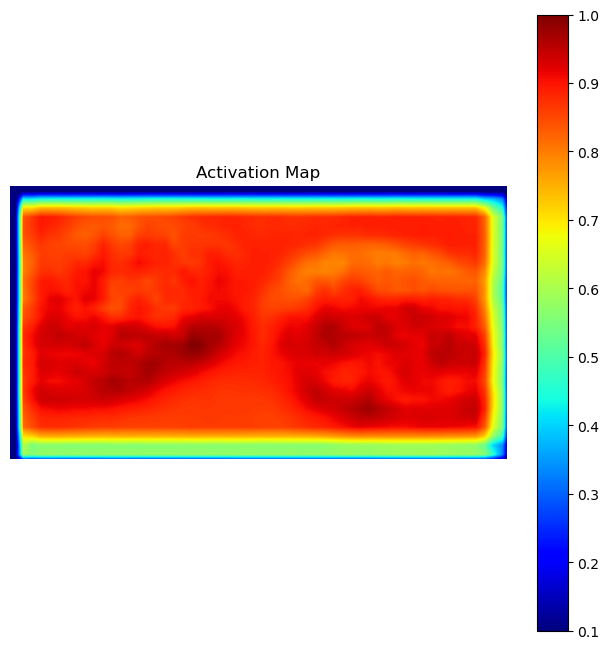

In [32]:
from skimage.transform import resize

activation_map_img = activation_map.squeeze()
activation_map_img_resized = resize(activation_map_img, mip_xy_depth.shape, mode='constant')
print (activation_map_img_resized.shape)
plt.figure(figsize=(8, 8))
plt.imshow(activation_map_img_resized, cmap='jet', vmin=0.1, vmax=1.0)
plt.colorbar()
plt.title('Activation Map')
plt.axis('off')
plt.show()


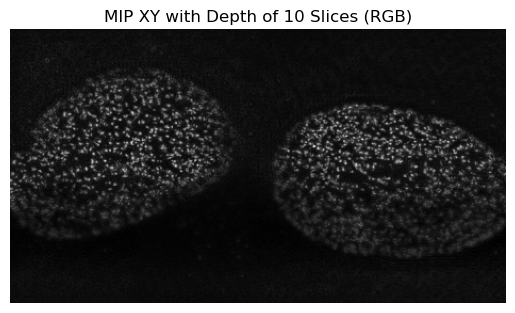

torch.Size([3, 257, 466])


In [33]:
import torchvision.transforms.functional as TF
import matplotlib.pyplot as plt

# Normalize the tensor to the range [0, 1]
mip_xy_depth_tensor_normalized = (mip_xy_depth_tensor - mip_xy_depth_tensor.min()) / (mip_xy_depth_tensor.max() - mip_xy_depth_tensor.min())

# Convert the tensor to a PIL image
mip_xy_depth_pil = TF.to_pil_image(mip_xy_depth_tensor_normalized)

# Convert the PIL image to RGB
mip_xy_depth_rgb = TF.to_tensor(mip_xy_depth_pil.convert("RGB"))

# Visualize the RGB image
plt.imshow(TF.to_pil_image(mip_xy_depth_rgb))
plt.title('MIP XY with Depth of 10 Slices (RGB)')
plt.axis('off')
plt.show()

print(mip_xy_depth_rgb.shape)

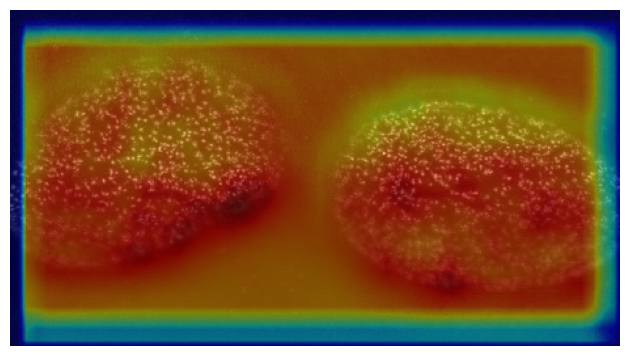

In [ ]:
from torchvision.transforms.functional import normalize, resize, to_pil_image


# Resize the CAM and overlay it
result = overlay_mask(to_pil_image(mip_xy_depth_rgb), to_pil_image(activation_map_img_resized, mode='F'), alpha=0.5)
# Display it
plt.imshow(result); plt.axis('off'); plt.tight_layout(); plt.show()

In [35]:
import numpy as np

# Convert the PIL image to a numpy array
result_np = np.array(result)

# Print the shape of the numpy array
print(result_np.shape)

(257, 466, 3)


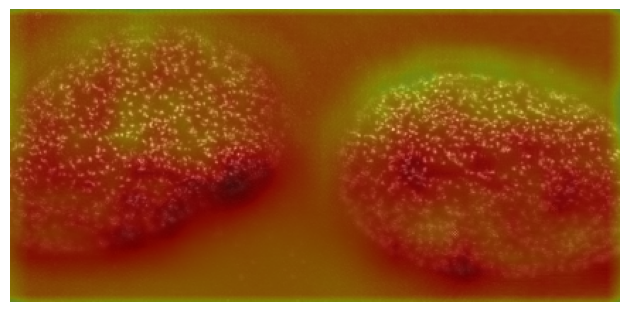

<Figure size 640x480 with 0 Axes>

In [62]:
plt.imshow(result_np[25:-25,15:-20,:])
plt.axis('off')
plt.tight_layout()
plt.show()
plt.savefig('current_figure.png')


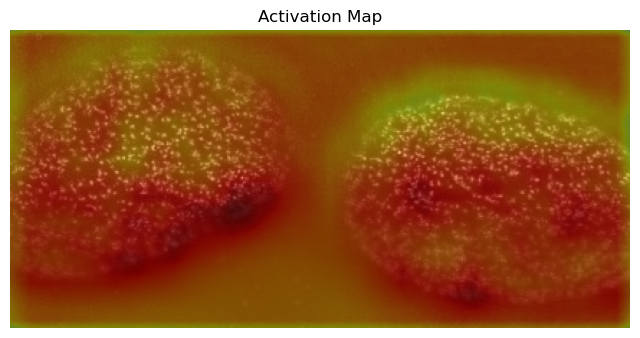

<Figure size 640x480 with 0 Axes>

In [60]:

plt.figure(figsize=(8, 8))
im = plt.imshow(result_np[25:-25,15:-20,:], cmap='jet', vmin=0, vmax=1.0)
# plt.colorbar(im,fraction=0.046, pad=0.04)
plt.title('Activation Map')
plt.axis('off')
plt.show()
plt.savefig('gradcam_result_2.png')


In [37]:
targets

NameError: name 'targets' is not defined